# Texas High Plains Climate & PDSI 

--- Starting Feature Engineering: Texas Climate & PDSI ---
Calculating Cumulative Precipitation and Extreme Heat Stress...
Encoding temporal seasonality (Sine/Cosine transformations)...
Processing Palmer Drought Severity Index (Step-Function)...
Generating biological climate graphs...


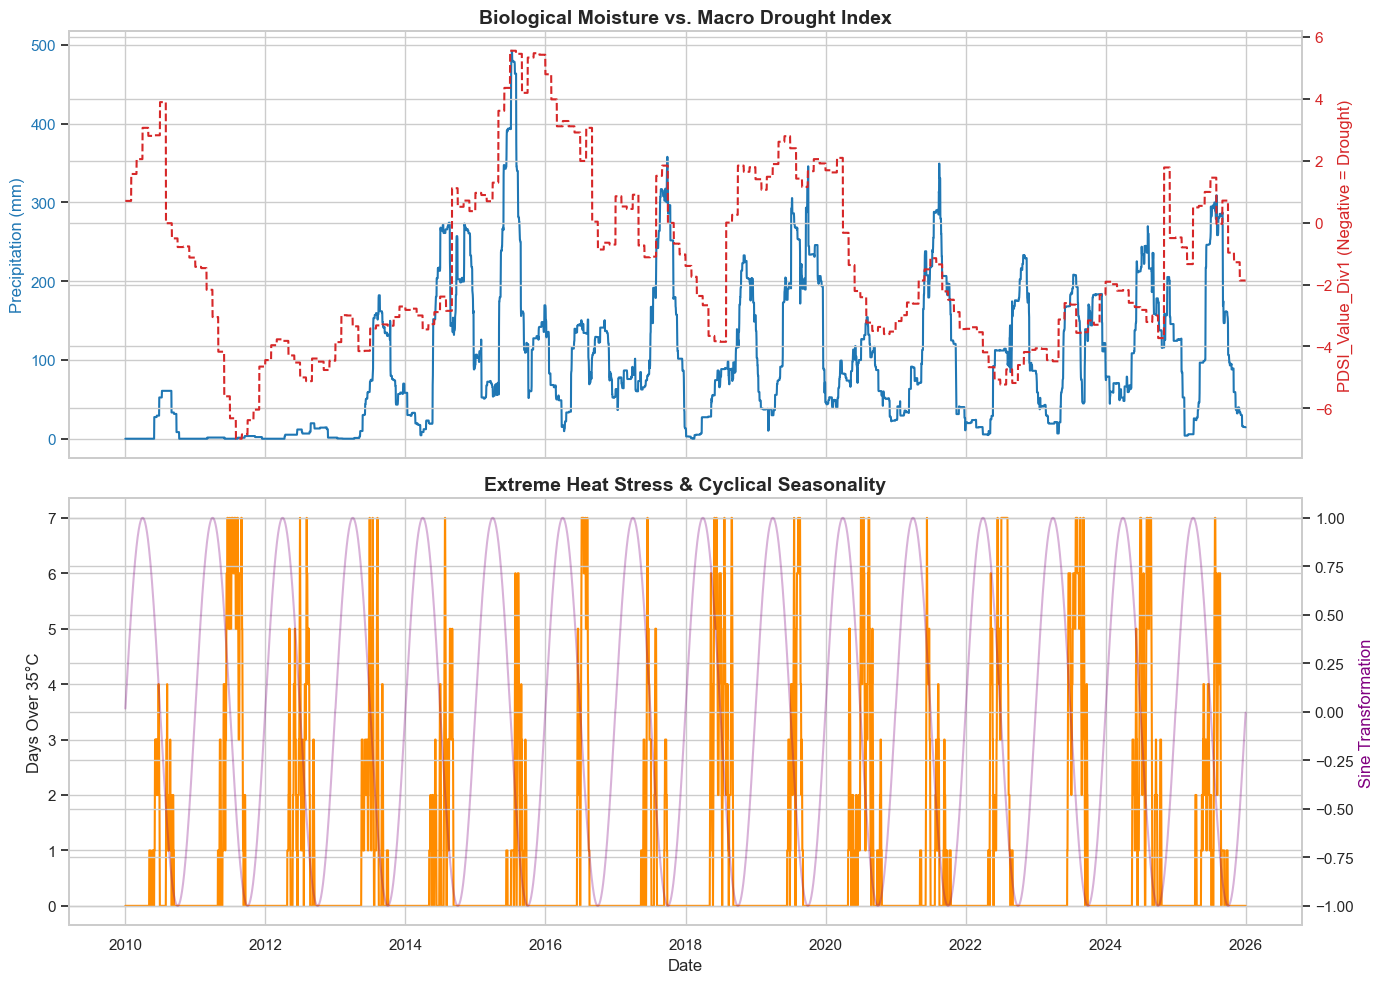


Success! Semi-cleaned Climate & PDSI dataset saved to: D:\MS_Data_Science_Thesis\Data_Cleaning\Semi_Clean_Datasets\climate_engineered_I.csv
           Date  Max_Temp_C  Precipitation_mm  Cum_Precip90  Heat_Stress_7  \
5839 2025-12-27        27.0               0.0          14.9            0.0   
5840 2025-12-28        18.0               0.0          14.6            0.0   
5841 2025-12-29         8.0               0.0          14.6            0.0   
5842 2025-12-30        14.0               0.0          14.6            0.0   
5843 2025-12-31        19.0               0.0          14.6            0.0   

       Day_Sin   Day_Cos  PDSI_Value_Div1  
5839 -0.073045  0.997329            -1.87  
5840 -0.055879  0.998438            -1.87  
5841 -0.038696  0.999251            -1.87  
5842 -0.021501  0.999769            -1.87  
5843 -0.004301  0.999991            -1.87  


In [15]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Directory Setup
base_dir = r"D:\MS_Data_Science_Thesis"
raw_folder = os.path.join(base_dir, r"Data_Extraction\Raw_Data_Folder")
clean_folder = os.path.join(base_dir, r"Data_Cleaning\Semi_Clean_Datasets")
os.makedirs(clean_folder, exist_ok=True)

# Adjust these filenames based on your actual raw data files
weather_file = os.path.join(raw_folder, "lubbock_climate_raw.csv")
pdsi_file = os.path.join(raw_folder, "texas_div1_pdsi_raw.csv")

def engineer_climate_features():
    print("--- Starting Feature Engineering: Texas Climate & PDSI ---")
    
    if not os.path.exists(weather_file) or not os.path.exists(pdsi_file):
        print("Error: Could not find one or both raw climate files.")
        return

    # 2. Load and Clean Daily Weather Data
    df_weather = pd.read_csv(weather_file)
    df_weather.columns = df_weather.columns.str.strip()
    df_weather['Date'] = pd.to_datetime(df_weather['Date'])
    df_weather = df_weather.sort_values('Date').reset_index(drop=True)
    
    # Handle missing daily data safely
    # If precipitation is blank, it generally means 0 rainfall
    if 'Precipitation_mm' in df_weather.columns:
        df_weather['Precipitation_mm'] = df_weather['Precipitation_mm'].fillna(0)
    # If temperature is blank, we linearly interpolate from the surrounding days
    if 'Max_Temp_C' in df_weather.columns:
        df_weather['Max_Temp_C'] = df_weather['Max_Temp_C'].interpolate(method='linear')
        
    print("Calculating Cumulative Precipitation and Extreme Heat Stress...")
    
    # 3. Complex Feature Generation: Biological Realities
    
    # 90-Day Cumulative Precipitation (Cum_Precip90)
    # min_periods=1 allows it to start calculating even before day 90
    df_weather['Cum_Precip90'] = df_weather['Precipitation_mm'].rolling(window=90, min_periods=1).sum()
    
    # Extreme Heat Days (Heat_Stress_7)
    # Threshold: 35 degrees Celsius (95F), typical threshold for cotton boll abortion
    STRESS_THRESHOLD = 35.0 
    df_weather['Is_Heat_Stress'] = (df_weather['Max_Temp_C'] > STRESS_THRESHOLD).astype(int)
    df_weather['Heat_Stress_7'] = df_weather['Is_Heat_Stress'].rolling(window=7, min_periods=1).sum()
    
    # Drop the temporary indicator column
    df_weather = df_weather.drop(columns=['Is_Heat_Stress'])
    
    # 4. Cyclical Biological Seasonality Encoding
    print("Encoding temporal seasonality (Sine/Cosine transformations)...")
    df_weather['Day_of_Year'] = df_weather['Date'].dt.dayofyear
    DAYS_IN_YEAR = 365.25 # Accounts for leap years
    
    df_weather['Day_Sin'] = np.sin(2 * np.pi * df_weather['Day_of_Year'] / DAYS_IN_YEAR)
    df_weather['Day_Cos'] = np.cos(2 * np.pi * df_weather['Day_of_Year'] / DAYS_IN_YEAR)
    
    # 5. Load and Process Monthly PDSI Data
    print("Processing Palmer Drought Severity Index (Step-Function)...")
    df_pdsi = pd.read_csv(pdsi_file)
    df_pdsi.columns = df_pdsi.columns.str.strip()
    
    # Convert 'YYYYMM' (e.g., 201001) to a Datetime object representing the 1st of that month
    df_pdsi['Date'] = pd.to_datetime(df_pdsi['Date'].astype(str), format='%Y%m')
    df_pdsi = df_pdsi.rename(columns={'Value': 'PDSI'})
    
    # 6. Merge Weather and PDSI
    # We use a left merge to align the monthly PDSI value to the 1st of the month on the daily calendar
    df_climate = pd.merge(df_weather, df_pdsi[['Date', 'PDSI_Value_Div1']], on='Date', how='left')
    
    # Apply the Step-Function (Forward Fill) to the PDSI
    # This holds the January PDSI value constant for every day in January until February 1st
    df_climate['PDSI_Value_Div1'] = df_climate['PDSI_Value_Div1'].ffill()
    
    # 7. Clean Data
    # Drop any lingering NaNs from the very beginning of the dataset
    df_cleaned = df_climate.dropna().copy()
    
    # 8. Data Visualization
    print("Generating biological climate graphs...")
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Top Plot: 90-Day Cumulative Precipitation vs PDSI
    color1 = 'tab:blue'
    ax1.plot(df_cleaned['Date'], df_cleaned['Cum_Precip90'], color=color1, linewidth=1.5, label='90-Day Cumulative Precip (mm)')
    ax1.set_ylabel('Precipitation (mm)', color=color1, fontsize=12)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # Create a secondary y-axis for the PDSI step-function
    ax1_twin = ax1.twinx()
    color2 = 'tab:red'
    ax1_twin.plot(df_cleaned['Date'], df_cleaned['PDSI_Value_Div1'], color=color2, linewidth=1.5, linestyle='--', label='PDSI_Value_Div1 (Monthly Step)')
    ax1_twin.set_ylabel('PDSI_Value_Div1 (Negative = Drought)', color=color2, fontsize=12)
    ax1_twin.tick_params(axis='y', labelcolor=color2)
    
    ax1.set_title('Biological Moisture vs. Macro Drought Index', fontsize=14, fontweight='bold')
    
    # Bottom Plot: Heat Stress and Seasonality
    ax2.plot(df_cleaned['Date'], df_cleaned['Heat_Stress_7'], color='darkorange', linewidth=1.5, label='7-Day Extreme Heat Count (>35°C)')
    ax2.set_ylabel('Days Over 35°C', fontsize=12)
    
    # Add the Sine Wave on a secondary axis to show the seasonal alignment
    ax2_twin = ax2.twinx()
    ax2_twin.plot(df_cleaned['Date'], df_cleaned['Day_Sin'], color='purple', alpha=0.3, label='Seasonality (Sine Wave)')
    ax2_twin.set_ylabel('Sine Transformation', color='purple', fontsize=12)
    
    ax2.set_title('Extreme Heat Stress & Cyclical Seasonality', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # 9. Export the intermediate dataset
    output_path = os.path.join(clean_folder, "climate_engineered_I.csv")
    
    # Keep only the engineered features for the master merge
    cols_to_keep = ['Date', 'Max_Temp_C', 'Precipitation_mm', 'Cum_Precip90', 'Heat_Stress_7', 'Day_Sin', 'Day_Cos', 'PDSI_Value_Div1']
    df_export = df_cleaned[cols_to_keep]
    
    df_export.to_csv(output_path, index=False)
    
    print(f"\nSuccess! Semi-cleaned Climate & PDSI dataset saved to: {output_path}")
    print(df_export.tail())

if __name__ == "__main__":
    engineer_climate_features()